# Face Recognition -  Using Deep Face

In [1]:
# !mkdir -p project
# !mkdir -p project/known_faces/


In [1]:
!tree -r project/

project/
├── mohanlal_test_1.jpeg
└── known_faces
    ├── mohanlal_1.jpg
    └── mammootty_1.jpg

1 directory, 3 files


In [6]:
# pip install deepface

In [9]:
# !ls face_recog*.ipynb

In [1]:
import os
import glob
print("Working Directory:", os.getcwd())
print("PKL files in ./data:", glob.glob("./data/*.pkl"))


Working Directory: /media/akashs/FA22E72622E6E69B/DATA1_disk/ACADEMICS/3_IPCS_Works
PKL files in ./data: ['./data/known_embeddings.pkl', './data/known_embeddings_emotion.pkl', './data/test_embedding.pkl', './data/test_embedding_emotion.pkl']


In [2]:
# Loading known_embeddings.pkl obtained from collab run
import pickle

with open("known_embeddings.pkl", "rb") as f:
    known_embeddings = pickle.load(f)

# Loading test_embeddings.pkl obtained from collab run

with open("test_embedding.pkl", "rb") as f:
    test_embedding = pickle.load(f)


In [3]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Extract only embeddings from known data
names = [name for name, emb in known_embeddings]
embeddings = np.array([emb for name, emb in known_embeddings])

# Compute similarity in one go
sims = cosine_similarity([test_embedding], embeddings)[0]

# Find the best match
max_sim_idx = np.argmax(sims)
if sims[max_sim_idx] > 0.5:
    match = names[max_sim_idx]
else:
    match = "Unknown"

print(f"✅ Recognized: {match} (Similarity: {sims[max_sim_idx]:.3f})")


✅ Recognized: mohanlal_1 (Similarity: 0.837)


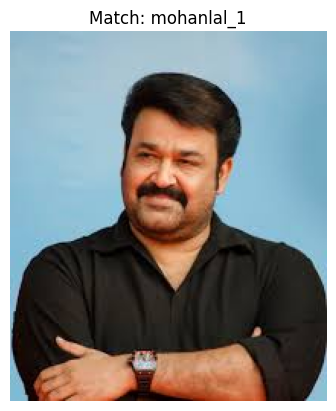

In [4]:

import cv2
from matplotlib import pyplot as plt

test_img = "./project/mohanlal_test_1.jpeg"
img = cv2.imread(test_img)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title(f"Match: {match}")
plt.axis("off")
plt.show()